In [3]:

import os
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("../data/cleaned_churn_data.csv")
os.makedirs("../graphs", exist_ok=True)

categories = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Contract",
    "Internet Service",
    "Payment Method",
    "Online Security",
    "Tech Support"
]

# Add the streaming columns that exist in your dataset
categories += [
    col for col in data.columns
    if "Streaming" in col and col not in categories
]

for col in categories:
    # Chart 1: Category distribution
    plt.figure(figsize=(7, 4))
    data[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(f"../graphs/{col.replace(' ', '_')}_distribution.png")
    plt.close()

    # Chart 2: Churn rate for each category
    churn_rate = (
        data.assign(Churned=(data["Churn Label"] == "Yes").astype(int))
        .groupby(col, dropna=False)["Churned"]
        .mean() * 100
    )

    plt.figure(figsize=(7, 4))
    churn_rate.plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(f"../graphs/{col.replace(' ', '_')}_churn_rate.png")
    plt.close()

print("Categorical distribution and churn-rate charts saved.")
print("Categories analyzed:", categories)

Categorical distribution and churn-rate charts saved.
Categories analyzed: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Contract', 'Internet Service', 'Payment Method', 'Online Security', 'Tech Support', 'Streaming TV', 'Streaming Movies']


In [4]:

# Final answers to the project questions

churn_rate = lambda col: (
    data.assign(Churned=(data["Churn Label"] == "Yes").astype(int))
    .groupby(col)["Churned"].mean() * 100
)

print("1. Contract type with highest churn:")
print(churn_rate("Contract").sort_values(ascending=False))

print("\n2. Payment method with highest churn:")
print(churn_rate("Payment Method").sort_values(ascending=False))

print("\n3. Churn rate by Tech Support:")
print(churn_rate("Tech Support"))

print("\n4. Churn rate by Internet Service:")
print(churn_rate("Internet Service"))

1. Contract type with highest churn:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churned, dtype: float64

2. Payment method with highest churn:
Payment Method
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churned, dtype: float64

3. Churn rate by Tech Support:
Tech Support
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churned, dtype: float64

4. Churn rate by Internet Service:
Internet Service
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churned, dtype: float64


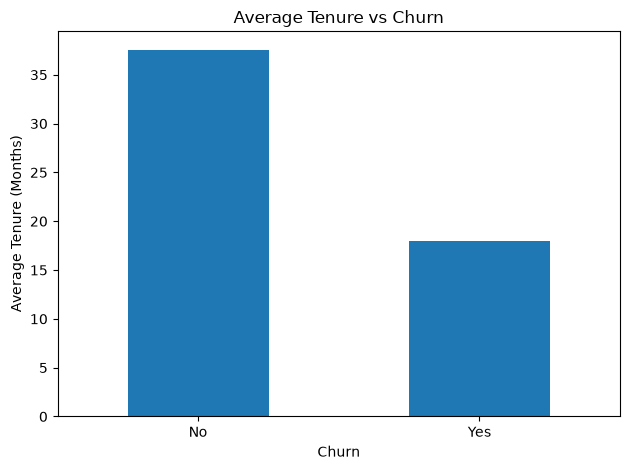

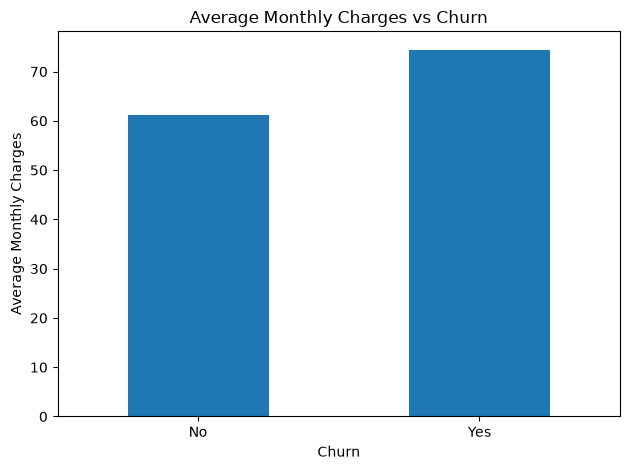

All 5 graphs are completed!


In [2]:

# Graph 4: Average Tenure vs Churn
tenure = data.groupby("Churn Label")["Tenure Months"].mean()

tenure.plot(kind="bar", title="Average Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../graphs/tenure_vs_churn.png")
plt.show()
plt.close()

# Graph 5: Average Monthly Charges vs Churn
charges = data.groupby("Churn Label")["Monthly Charges"].mean()

charges.plot(kind="bar", title="Average Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../graphs/monthly_charges_vs_churn.png")
plt.show()
plt.close()

print("All 5 graphs are completed!")

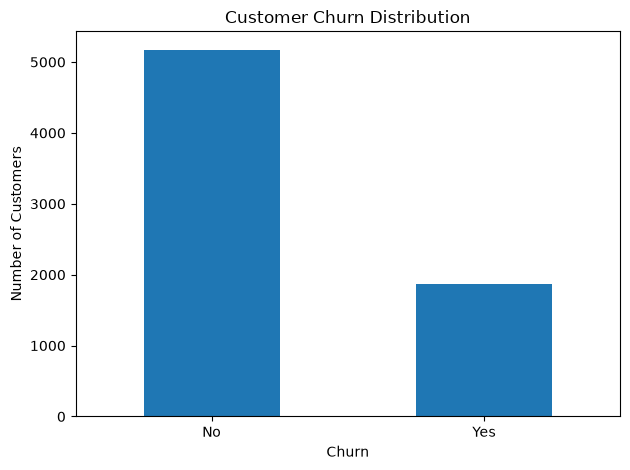

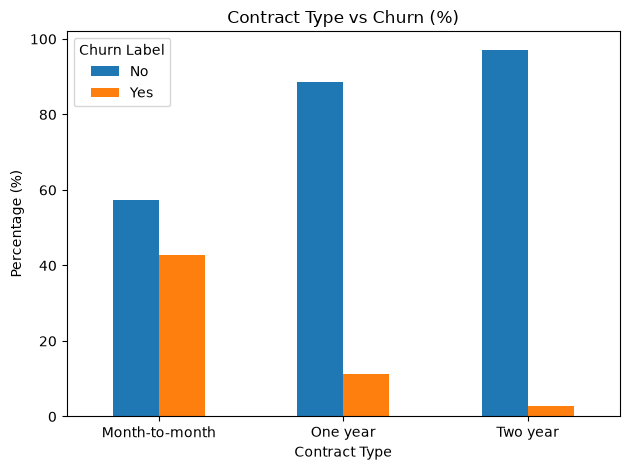

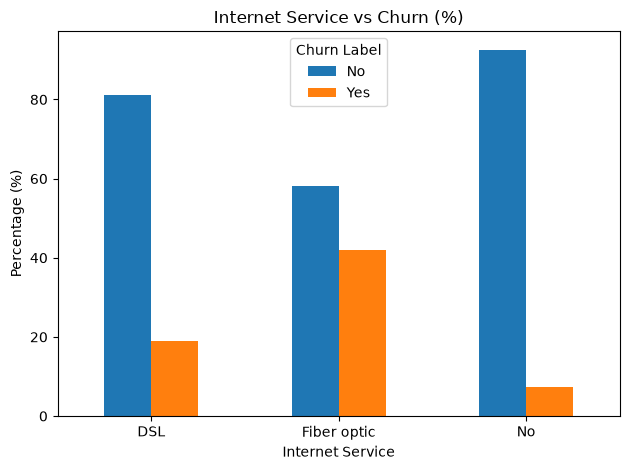

All 3 graphs saved successfully!


In [4]:

import os
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("../data/cleaned_churn_data.csv")

# Create folder to save graphs
os.makedirs("../graphs", exist_ok=True)

# Graph 1: Churn Distribution
churn_counts = data["Churn Label"].value_counts()

churn_counts.plot(kind="bar", title="Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../graphs/churn_distribution.png")
plt.show()
plt.close()

# Graph 2: Contract vs Churn
contract_data = pd.crosstab(
    data["Contract"], data["Churn Label"], normalize="index"
) * 100

contract_data.plot(kind="bar", title="Contract Type vs Churn (%)")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../graphs/contract_vs_churn.png")
plt.show()
plt.close()

# Graph 3: Internet Service vs Churn
internet_data = pd.crosstab(
    data["Internet Service"], data["Churn Label"], normalize="index"
) * 100

internet_data.plot(kind="bar", title="Internet Service vs Churn (%)")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../graphs/internet_service_vs_churn.png")
plt.show()
plt.close()

print("All 3 graphs saved successfully!")

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset
data = pd.read_csv("../data/cleaned_churn_data.csv")

print("Dataset shape:", data.shape)
print("Categorical analysis started successfully!")
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
data = pd.read_csv("../data/cleaned_churn_data.csv")

# 1. Churn distribution
print("CHURN DISTRIBUTION")
print(data["Churn Label"].value_counts())
print(data["Churn Label"].value_counts(normalize=True) * 100)

# 2. Contract vs Churn
print("\nCONTRACT VS CHURN")
print(pd.crosstab(data["Contract"], data["Churn Label"], normalize="index") * 100)

# 3. Internet Service vs Churn
print("\nINTERNET SERVICE VS CHURN")
print(pd.crosstab(data["Internet Service"], data["Churn Label"], normalize="index") * 100)

# 4. Payment Method vs Churn
print("\nPAYMENT METHOD VS CHURN")
print(pd.crosstab(data["Payment Method"], data["Churn Label"], normalize="index") * 100)

# 5. Tech Support vs Churn
print("\nTECH SUPPORT VS CHURN")
print(pd.crosstab(data["Tech Support"], data["Churn Label"], normalize="index") * 100)

# 6. Online Security vs Churn
print("\nONLINE SECURITY VS CHURN")
print(pd.crosstab(data["Online Security"], data["Churn Label"], normalize="index") * 100)

print("\nCategorical analysis completed!")

Dataset shape: (7043, 26)
Categorical analysis started successfully!
CHURN DISTRIBUTION
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

CONTRACT VS CHURN
Churn Label            No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

INTERNET SERVICE VS CHURN
Churn Label              No        Yes
Internet Service                      
DSL               81.040892  18.959108
Fiber optic       58.107235  41.892765
No                92.595020   7.404980

PAYMENT METHOD VS CHURN
Churn Label                       No        Yes
Payment Method                                 
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700

TECH SUPPORT VS CHURN
Churn Lab